STEP 1. 데이터 IMPORT

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

In [ ]:
smpl_sub = pd.read_csv('/content/drive/MyDrive/datasets/wine_quality/sample_submission.csv')
train = pd.read_csv('/content/drive/MyDrive/datasets/wine_quality/train.csv')
test = pd.read_csv('/content/drive/MyDrive/datasets/wine_quality/test.csv')

In [ ]:
train = train.drop('index', axis=1)
test_index = test['index']
test = test.drop('index', axis=1)

In [ ]:
# 범주형 변수(type) 인코딩: white는 0, red는 1로 변환
train['type'] = train['type'].map({'white': 0, 'red': 1})
test['type'] = test['type'].map({'white': 0, 'red': 1})

In [ ]:
X = train.drop('quality', axis=1)
y = train['quality']
# 학습용 데이터, 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

타겟변수 분포 확인 -> 데이터 불균형이 심함 -> SMOTE 이용

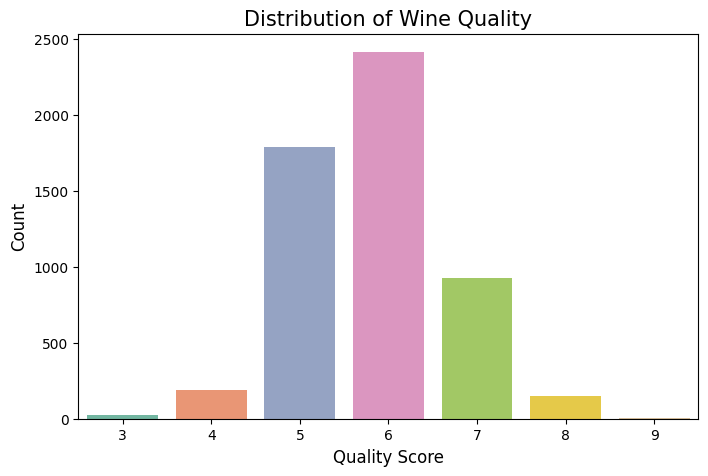

품질 점수별 데이터 개수:
 quality
3      26
4     186
5    1788
6    2416
7     924
8     152
9       5
Name: count, dtype: int64


In [ ]:
# 타겟 변수(quality) 분포 확인
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=train, palette='Set2')

plt.title('Distribution of Wine Quality', fontsize=15)
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

print("품질 점수별 데이터 개수:\n", train['quality'].value_counts().sort_index())

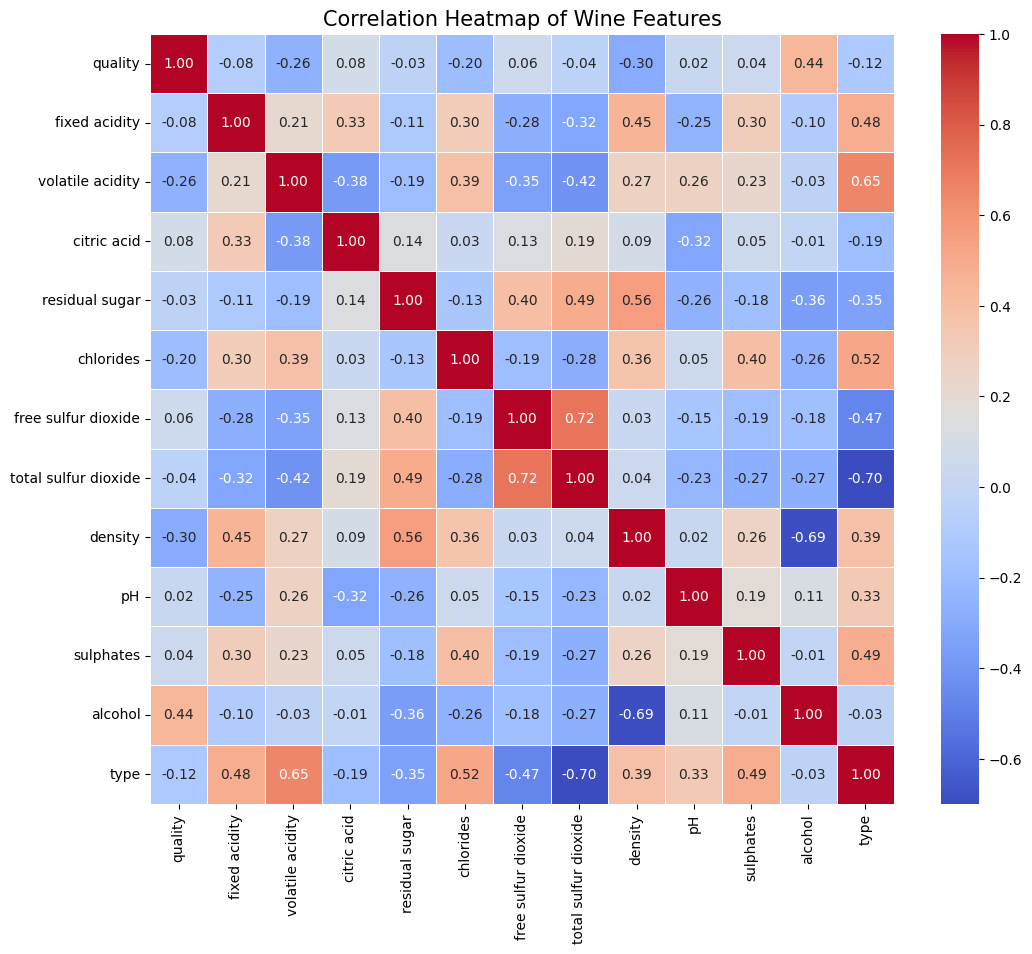


[ quality와 다른 변수들 간의 상관계수 ]
quality                 1.000000
alcohol                 0.439615
citric acid             0.079157
free sulfur dioxide     0.055574
sulphates               0.042068
pH                      0.017931
residual sugar         -0.032848
total sulfur dioxide   -0.039732
fixed acidity          -0.076506
type                   -0.118280
chlorides              -0.198148
volatile acidity       -0.261557
density                -0.299831
Name: quality, dtype: float64


In [ ]:
# 변수 간의 상관관계 히트맵 (Correlation Heatmap)
plt.figure(figsize=(12, 10))

# 상관계수 계산
corr_matrix = train.corr()

# 히트맵 그리기 (annot=True: 수치 표시, cmap: 색상 테마)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Wine Features', fontsize=15)
plt.show()

# (참고) quality와 다른 변수들 간의 상관계수만 따로 뽑아서 보기
print("\n[ quality와 다른 변수들 간의 상관계수 ]")
print(corr_matrix['quality'].sort_values(ascending=False))

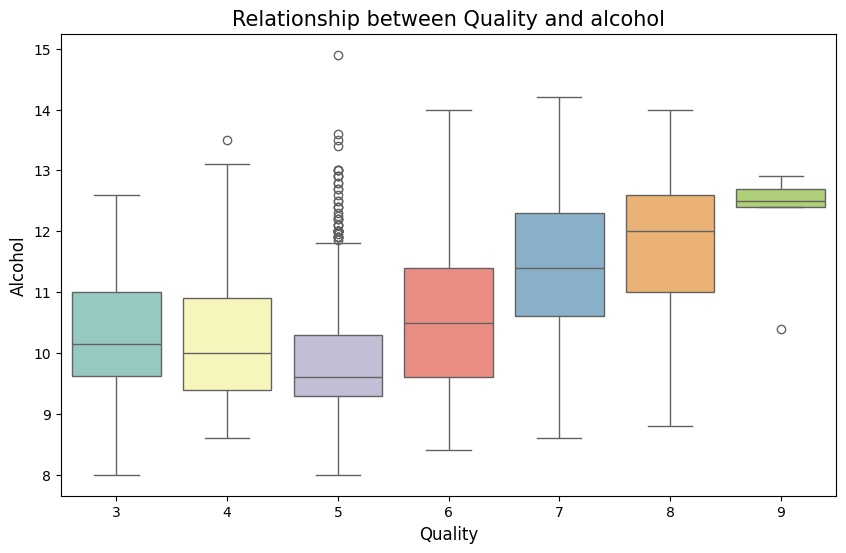

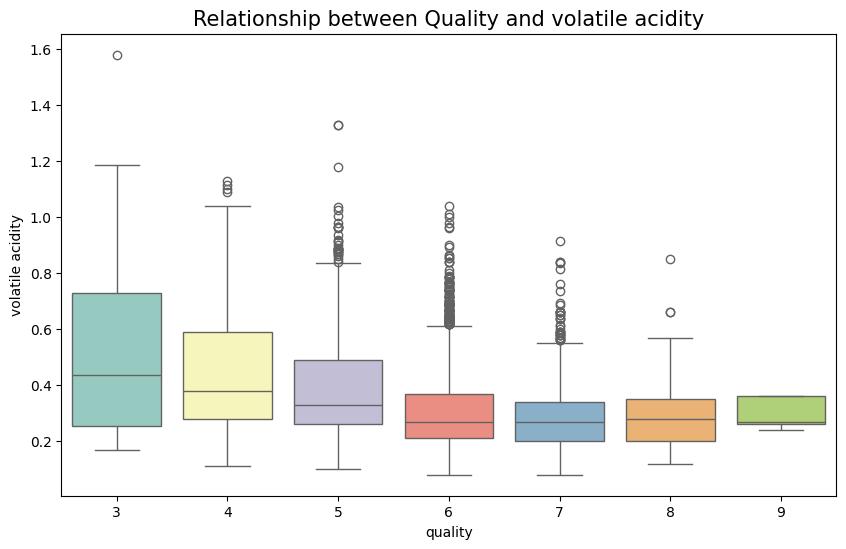

In [ ]:
# 주요 피처와 quality 간의 관계 시각화
target_feature = 'alcohol'

plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y=target_feature, data=train, palette='Set3')

plt.title(f'Relationship between Quality and {target_feature}', fontsize=15)
plt.xlabel('Quality', fontsize=12)
plt.ylabel(target_feature.capitalize(), fontsize=12)
plt.show()

# 추가로 또 다른 주요 변수(volatile acidity 휘발성 산)도 확인해보기
target_feature_2 = 'volatile acidity'
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y=target_feature_2, data=train, palette='Set3')
plt.title(f'Relationship between Quality and {target_feature_2}', fontsize=15)
plt.show()

In [ ]:
# SMOTE + 언더샘플링 사용
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter

X = train.drop('quality', axis=1)
y = train['quality']

print("Before:", Counter(y))

pipeline = Pipeline([
    ('over', SMOTE(sampling_strategy={3: 200, 4: 400, 8: 400, 9: 100}, k_neighbors=3, random_state=42)),
    ('under', RandomUnderSampler(sampling_strategy={5: 1200, 6: 1500}, random_state=42))
])

X_res, y_res = pipeline.fit_resample(X_train, y_train)
print("After:", Counter(y_res))

Before: Counter({6: 2416, 5: 1788, 7: 924, 4: 186, 8: 152, 3: 26, 9: 5})
After: Counter({6: 1500, 5: 1200, 7: 739, 4: 400, 8: 400, 3: 200, 9: 100})


In [ ]:
train.isnull().sum()

,0
quality,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


In [ ]:
# 피처 엔지니어링 — 트리 모델 성능 끌어올리는데 좋음
train['total_acidity'] = train['fixed acidity'] + train['volatile acidity']
train['sulfur_ratio'] = train['free sulfur dioxide'] / train['total sulfur dioxide']
train['alcohol_density_ratio'] = train['alcohol'] / train['density']

In [ ]:
# (1) Decision Tree
from sklearn.metrics import accuracy_score, f1_score, classification_report
dt_clf = DecisionTreeClassifier(max_depth=8, min_samples_split=20, min_samples_leaf=10, random_state=42)
dt_clf.fit(X_res, y_res)
dt_pred = dt_clf.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred, average='macro')

print(f"Accuracy: {dt_acc:.4f}")
print(f"Macro F1: {dt_f1:.4f}")

Accuracy: 0.4500
Macro F1: 0.2394


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# 탐색할 파라미터 조합 정의
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy'],
}

# GridSearch 설정
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                    # 5-fold 교차검증
    scoring='f1_macro',      # 불균형 데이터라 macro F1 사용
    n_jobs=-1,               # 모든 CPU 코어 사용
    verbose=1                # 진행상황 출력
)

# 학습 (SMOTE 적용된 데이터로)
grid_search.fit(X_res, y_res)

# 결과 출력
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# 최적 모델로 테스트 평가
best_dt = grid_search.best_estimator_
dt_pred = best_dt.predict(X_test)

print(f"\nTest Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Test Macro F1: {f1_score(y_test, dt_pred, average='macro'):.4f}")
print("\n", classification_report(y_test, dt_pred))

Fitting 5 folds for each of 280 candidates, totalling 1400 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Score: 0.657062074312012

Test Accuracy: 0.5591
Test Macro F1: 0.3483

               precision    recall  f1-score   support

           3       0.05      0.20      0.08         5
           4       0.24      0.30      0.27        37
           5       0.59      0.63      0.61       358
           6       0.66      0.54      0.59       484
           7       0.50      0.54      0.52       185
           8       0.29      0.50      0.37        30
           9       0.00      0.00      0.00         1

    accuracy                           0.56      1100
   macro avg       0.33      0.39      0.35      1100
weighted avg       0.58      0.56      0.57      1100



In [ ]:
# (2) Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
rf_clf = RandomForestClassifier(n_estimators=300, max_depth=15, min_samples_split=5,min_samples_leaf=2,
                                max_features='sqrt', n_jobs=-1,random_state=42)
rf_clf.fit(X_res, y_res)

rf_acc = accuracy_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, dt_pred, average='macro')

print(f"Accuracy: {rf_acc:.4f}")
print(f"Macro F1: {rf_f1:.4f}")

Accuracy: 0.5591
Macro F1: 0.3483


In [ ]:
# GridSearchCV 를 이용한 하이퍼파라미터 튜닝
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_res, y_res)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
rf_pred = best_rf.predict(X_test)

print(f"\nTest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Test Macro F1: {f1_score(y_test, rf_pred, average='macro'):.4f}")
print("\n", classification_report(y_test, rf_pred))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.7723546840334059

Test Accuracy: 0.6245
Test Macro F1: 0.3665

               precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.22      0.16      0.19        37
           5       0.66      0.65      0.66       358
           6       0.63      0.68      0.65       484
           7       0.62      0.56      0.59       185
           8       0.48      0.47      0.47        30
           9       0.00      0.00      0.00         1

    accuracy                           0.62      1100
   macro avg       0.37      0.36      0.37      1100
weighted avg       0.62      0.62      0.62      1100



In [ ]:
# (3) XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost는 라벨이 0부터 시작해야 해서 인코딩 필요 (quality는 3~9)
le = LabelEncoder()
y_res_enc = le.fit_transform(y_res)
y_test_enc = le.transform(y_test)

xgb_clf = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, eval_metric='mlogloss', n_jobs=-1)
xgb_clf.fit(X_res, y_res_enc)

xgb_pred = le.inverse_transform(xgb_clf.predict(X_test))

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred, average='macro')

print(f"Accuracy: {xgb_acc:.4f}")
print(f"Macro F1: {xgb_f1:.4f}")

Accuracy: 0.6064
Macro F1: 0.3622


In [ ]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

# 라벨 인코딩 (XGBoost 필수)
le = LabelEncoder()
y_res_enc = le.fit_transform(y_res)

# 1. 탐색 공간 정의
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 500, 50),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'gamma': hp.uniform('gamma', 0, 1),
    'reg_alpha': hp.uniform('reg_alpha', 0, 2),
    'reg_lambda': hp.uniform('reg_lambda', 0, 2),
}

# 2. 목적 함수 정의 (Hyperopt는 최소화하므로 -score 반환)
def objective(params):
    # quniform은 float 반환하므로 int 변환 필요
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model = XGBClassifier(**params, random_state=42, eval_metric='mlogloss',n_jobs=-1)

    # 5-fold 교차검증 (macro F1)
    score = cross_val_score(model, X_res, y_res_enc,
                            cv=5, scoring='f1_macro', n_jobs=-1).mean()

    return {'loss': -score, 'status': STATUS_OK}  # 최대화하려면 음수로

# 3. 최적화 실행
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,        # TPE 알고리즘 (베이지안 최적화)
    max_evals=100,           # 100번 시도
    trials=trials,
    rstate=np.random.default_rng(42)
)

# 4. 최적 파라미터 추출
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Best Parameters:", best)
print(f"Best CV Score: {-min(trials.losses()):.4f}")

# 5. 최적 파라미터로 최종 학습 및 평가
final_xgb = XGBClassifier(
    **best,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)
final_xgb.fit(X_res, y_res_enc)
xgb_pred = le.inverse_transform(final_xgb.predict(X_test))

print(f"\nTest Accuracy: {accuracy_score(y_test, xgb_pred):.4f}")
print(f"Test Macro F1: {f1_score(y_test, xgb_pred, average='macro'):.4f}")
print("\n", classification_report(y_test, xgb_pred))

100%|██████████| 100/100 [17:09<00:00, 10.30s/trial, best loss: -0.7612496684708223]
Best Parameters: {'colsample_bytree': np.float64(0.6126168309643049), 'gamma': np.float64(0.003122046022560887), 'learning_rate': np.float64(0.10849395895581772), 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 400, 'reg_alpha': np.float64(0.44115545352767027), 'reg_lambda': np.float64(0.8950697477276499), 'subsample': np.float64(0.8733900149303565)}
Best CV Score: 0.7612

Test Accuracy: 0.6164
Test Macro F1: 0.3598

               precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.19      0.14      0.16        37
           5       0.64      0.67      0.65       358
           6       0.64      0.65      0.65       484
           7       0.60      0.56      0.58       185
           8       0.54      0.43      0.48        30
           9       0.00      0.00      0.00         1

    accuracy                           0.62      110

KeyError: 'index'

In [ ]:
# ============================================
# Submission 파일 생성 (XGBoost - Hyperopt 튜닝 모델)
# ============================================

# 1. test에도 train과 동일한 피처 엔지니어링 적용
test['total_acidity'] = test['fixed acidity'] + test['volatile acidity']
test['sulfur_ratio'] = test['free sulfur dioxide'] / test['total sulfur dioxide']
test['alcohol_density_ratio'] = test['alcohol'] / test['density']

# 2. 학습 시 사용한 컬럼 순서와 동일하게 맞추기
test = test[X_res.columns]

# 3. 컬럼 일치 확인 (안전장치)
print("X_res columns:", list(X_res.columns))
print("test columns: ", list(test.columns))
assert list(X_res.columns) == list(test.columns), "컬럼이 일치하지 않습니다!"
print(" 컬럼 일치 확인")

# 4. 결측치 체크 (sulfur_ratio에서 0으로 나누기 가능성)
print("\n결측치 확인:")
print(test.isnull().sum())
print("\n무한대 값 확인:")
print(np.isinf(test).sum())

# 5. 예측 (Hyperopt로 튜닝한 final_xgb 사용)
test_pred_enc = final_xgb.predict(test)
test_pred = le.inverse_transform(test_pred_enc)  # 0~6 → 3~9 복원

# 6. submission 파일 생성 (test_index는 Cell 4에서 저장한 원본 index)
submission = pd.DataFrame({
    'index': test_index,
    'quality': test_pred
})

# 7. 저장
submission.to_csv('/content/drive/MyDrive/datasets/wine_quality/submission.csv', index=False)

# 8. 결과 확인
print("\n📋 Submission 미리보기:")
print(submission.head(10))
print(f"\n총 {len(submission)}개 행")
print(f"\n예측 분포:")
print(submission['quality'].value_counts().sort_index())

# 9. sample_submission 형식과 일치하는지 확인
print(f"\nSample 형식: {smpl_sub.columns.tolist()}, shape: {smpl_sub.shape}")
print(f"내 submission: {submission.columns.tolist()}, shape: {submission.shape}")

X_res columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type']
test columns:  ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'type']
 컬럼 일치 확인

결측치 확인:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
type                    0
dtype: int64

무한대 값 확인:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates            